In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e2/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e2/train.csv
/kaggle/input/competitions/playground-series-s6e2/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/train.csv')
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e2/test.csv")
sample = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/sample_submission.csv')

In [3]:
train

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [4]:
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()

In [5]:
new = np.array(encode.fit_transform(train['Heart Disease']))

array([1, 0, 0, ..., 1, 1, 0])

In [6]:
train.drop(['Heart Disease'],axis=1)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6


In [7]:
train['Heart Disease'] = new

In [8]:
train

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,0
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,0
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,1
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,1


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [10]:
train['BP'].describe()

count    630000.000000
mean        130.497433
std          14.975802
min          94.000000
25%         120.000000
50%         130.000000
75%         140.000000
max         200.000000
Name: BP, dtype: float64

In [11]:
x_train = train.drop(['id','Heart Disease'],axis=1)
x_test = test.drop(['id'],axis=1)
y_train = train['Heart Disease']

In [12]:
x_train

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6


In [13]:
y_train

0         1
1         0
2         0
3         0
4         1
         ..
629995    0
629996    0
629997    1
629998    1
629999    0
Name: Heart Disease, Length: 630000, dtype: int64

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


lr = LogisticRegression(random_state = 42,l1_ratio=1,solver="saga",max_iter=100)
scale = StandardScaler()
knn = KNeighborsClassifier(n_neighbors = 2)

In [15]:
x_scaled = scale.fit_transform(x_train)
x_scaled = pd.DataFrame(x_scaled)
x_scaled

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.467921,0.631760,0.806994,1.435822,-0.178490,-0.294858,-0.982858,0.271190,1.628894,3.040655,0.998051,1.939721,1.221087
1,-0.258797,0.631760,-2.715729,-0.367088,2.374837,-0.294858,1.019582,0.951359,-0.613913,-0.754928,-0.836168,-0.564825,-0.830189
2,0.225682,-1.582881,-1.541488,1.970017,-1.692672,-0.294858,1.019582,-0.095054,-0.613913,-0.754928,-0.836168,-0.564825,-0.830189
3,-1.227755,-1.582881,-0.367247,0.233882,-0.475388,-0.294858,1.019582,-0.147375,-0.613913,0.299400,0.998051,-0.564825,-0.830189
4,0.467921,0.631760,0.806994,0.634529,-0.326939,-0.294858,1.019582,-1.455391,1.628894,3.251520,0.998051,3.191993,-0.830189
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,0.225682,-1.582881,-2.715729,-1.368705,-0.564458,-0.294858,-0.982858,-1.089147,-0.613913,-0.754928,-0.836168,-0.564825,1.221087
629996,-0.016558,0.631760,0.806994,-0.166765,0.118409,3.391458,1.019582,-0.147375,-0.613913,-0.754928,0.998051,-0.564825,-0.830189
629997,1.557998,0.631760,0.806994,-0.033216,0.890344,-0.294858,-0.982858,-0.199696,-0.613913,-0.754928,-0.836168,1.939721,1.221087
629998,-0.258797,0.631760,0.806994,0.634529,-1.366083,-0.294858,1.019582,0.218870,-0.613913,-0.754928,-0.836168,-0.564825,0.708268


In [ ]:
print(accuracy_score(y_pred,sample['Heart Disease']))

In [ ]:
ans = []
for i in range(1,5):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    ans.append(accuracy_score(y_pred,sample['Heart Disease']))

In [ ]:
ans

## Some preprocessing

In [17]:
Train_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/train.csv')
Test_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e2/test.csv")
sample = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/sample_submission.csv')

In [18]:
Train_data

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [25]:
X_train = Train_data.drop(['id'],axis=1)
X_train

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [26]:
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()
new = np.array(encode.fit_transform(train['Heart Disease']))
X_train.drop(['Heart Disease'],axis=1)
X_train['Heart Disease'] = new

In [27]:
X_train

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,0
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,0
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,1
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,1


In [31]:
Y_train = X_train['Heart Disease']
Y_train

0         1
1         0
2         0
3         0
4         1
         ..
629995    0
629996    0
629997    1
629998    1
629999    0
Name: Heart Disease, Length: 630000, dtype: int64

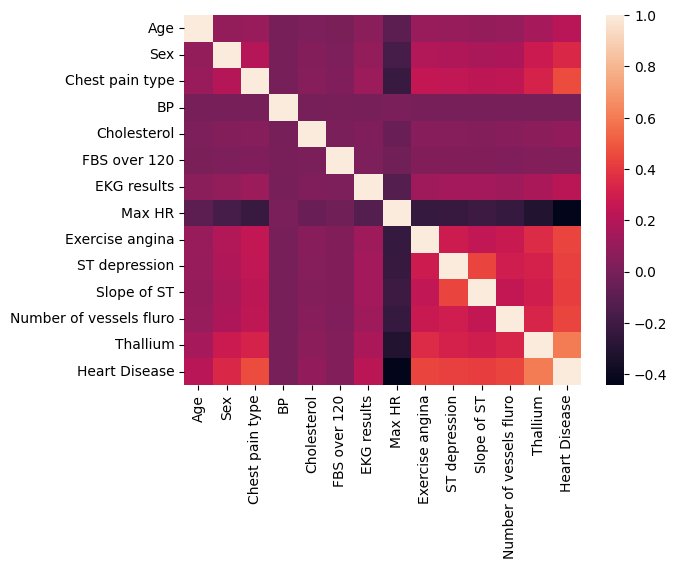

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
Age,1.000000,0.088397,0.109453,-0.003960,0.019485,0.013354,0.057431,-0.097542,0.110153,0.103064,0.096337,0.102758,0.150124,0.212091
Sex,0.088397,1.000000,0.195893,-0.003355,0.038373,0.020333,0.093590,-0.176186,0.192705,0.181093,0.169854,0.174700,0.275282,0.342446
Chest pain type,0.109453,0.195893,1.000000,-0.003587,0.045463,0.023036,0.120907,-0.221806,0.246211,0.240228,0.233849,0.236787,0.319887,0.460684
BP,-0.003960,-0.003355,-0.003587,1.000000,-0.004597,-0.000784,-0.003738,0.004391,-0.003295,-0.004024,-0.003203,-0.003143,-0.005884,-0.005181
Cholesterol,0.019485,0.038373,0.045463,-0.004597,1.000000,0.006212,0.024948,-0.048575,0.049774,0.044678,0.040197,0.048800,0.061817,0.082753
FBS over 120,0.013354,0.020333,0.023036,-0.000784,0.006212,1.000000,0.016258,-0.024895,0.027971,0.031324,0.030327,0.025691,0.032895,0.033570
EKG results,0.057431,0.093590,0.120907,-0.003738,0.024948,0.016258,1.000000,-0.125047,0.128814,0.149273,0.144468,0.130943,0.169017,0.218961
Max HR,-0.097542,-0.176186,-0.221806,0.004391,-0.048575,-0.024895,-0.125047,1.000000,-0.236232,-0.229462,-0.206190,-0.236319,-0.306912,-0.440985
Exercise angina,0.110153,0.192705,0.246211,-0.003295,0.049774,0.027971,0.128814,-0.236232,1.000000,0.281298,0.245243,0.270413,0.357076,0.441864
ST depression,0.103064,0.181093,0.240228,-0.004024,0.044678,0.031324,0.149273,-0.229462,0.281298,1.000000,0.438240,0.293642,0.316891,0.430641


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_train.corr()
sns.heatmap(corr)
plt.show()
corr

In [34]:
X_train = X_train.drop(['BP','Cholesterol','Heart Disease'],axis=1)
X_train

,Age,Sex,Chest pain type,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,4,0,0,158,1,3.6,2,2,7
1,52,1,1,0,2,171,0,0.0,1,0,3
2,56,0,2,0,2,151,0,0.0,1,0,3
3,44,0,3,0,2,150,0,1.0,2,0,3
4,58,1,4,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,0,0,132,0,0.0,1,0,7
629996,54,1,4,1,2,150,0,0.0,2,0,3
629997,67,1,4,0,0,149,0,0.0,1,2,7
629998,52,1,4,0,2,157,0,0.0,1,0,6


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

lr = LogisticRegression(random_state = 42,l1_ratio=1,solver="saga",max_iter=100)
scale = StandardScaler()
knn = KNeighborsClassifier(n_neighbors = 2)

In [36]:
X_scaled = scale.fit_transform(X_train)
X_scaled = pd.DataFrame(X_scaled)
X_scaled

,0,1,2,3,4,5,6,7,8,9,10
0,0.467921,0.631760,0.806994,-0.294858,-0.982858,0.271190,1.628894,3.040655,0.998051,1.939721,1.221087
1,-0.258797,0.631760,-2.715729,-0.294858,1.019582,0.951359,-0.613913,-0.754928,-0.836168,-0.564825,-0.830189
2,0.225682,-1.582881,-1.541488,-0.294858,1.019582,-0.095054,-0.613913,-0.754928,-0.836168,-0.564825,-0.830189
3,-1.227755,-1.582881,-0.367247,-0.294858,1.019582,-0.147375,-0.613913,0.299400,0.998051,-0.564825,-0.830189
4,0.467921,0.631760,0.806994,-0.294858,1.019582,-1.455391,1.628894,3.251520,0.998051,3.191993,-0.830189
...,...,...,...,...,...,...,...,...,...,...,...
629995,0.225682,-1.582881,-2.715729,-0.294858,-0.982858,-1.089147,-0.613913,-0.754928,-0.836168,-0.564825,1.221087
629996,-0.016558,0.631760,0.806994,3.391458,1.019582,-0.147375,-0.613913,-0.754928,0.998051,-0.564825,-0.830189
629997,1.557998,0.631760,0.806994,-0.294858,-0.982858,-0.199696,-0.613913,-0.754928,-0.836168,1.939721,1.221087
629998,-0.258797,0.631760,0.806994,-0.294858,1.019582,0.218870,-0.613913,-0.754928,-0.836168,-0.564825,0.708268


In [38]:
Test_data

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,899995,58,1,2,120,222,0,0,172,0,1.0,1,0,7
269996,899996,58,1,4,132,289,0,0,172,0,2.8,2,0,3
269997,899997,63,1,3,108,201,1,0,158,0,0.8,1,0,3
269998,899998,59,1,4,120,274,0,2,163,0,0.5,1,0,3


In [46]:
Test_data = Test_data.drop(['BP','Cholesterol'], axis=1)
Test_data = Test_data.drop(['id'], axis=1)

In [47]:
ans = []
for i in range(1,5):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train,Y_train)
    Y_pred = knn.predict(Test_data)
    ans.append(accuracy_score(Y_pred,sample['Heart Disease']))

In [49]:
ans

[0.5522444444444444,
 0.6362555555555556,
 0.5572222222222222,
 0.5992481481481482]